Training LASSO Baseline...
Running N-HiTS Inference...
Total Trainable Parameters: 216,642

--- RESULTS (N=8456) ---
LASSO       | RMSE: 6.7530 | MAE: 4.1626
N-HiTS      | RMSE: 6.7594 | MAE: 4.1508


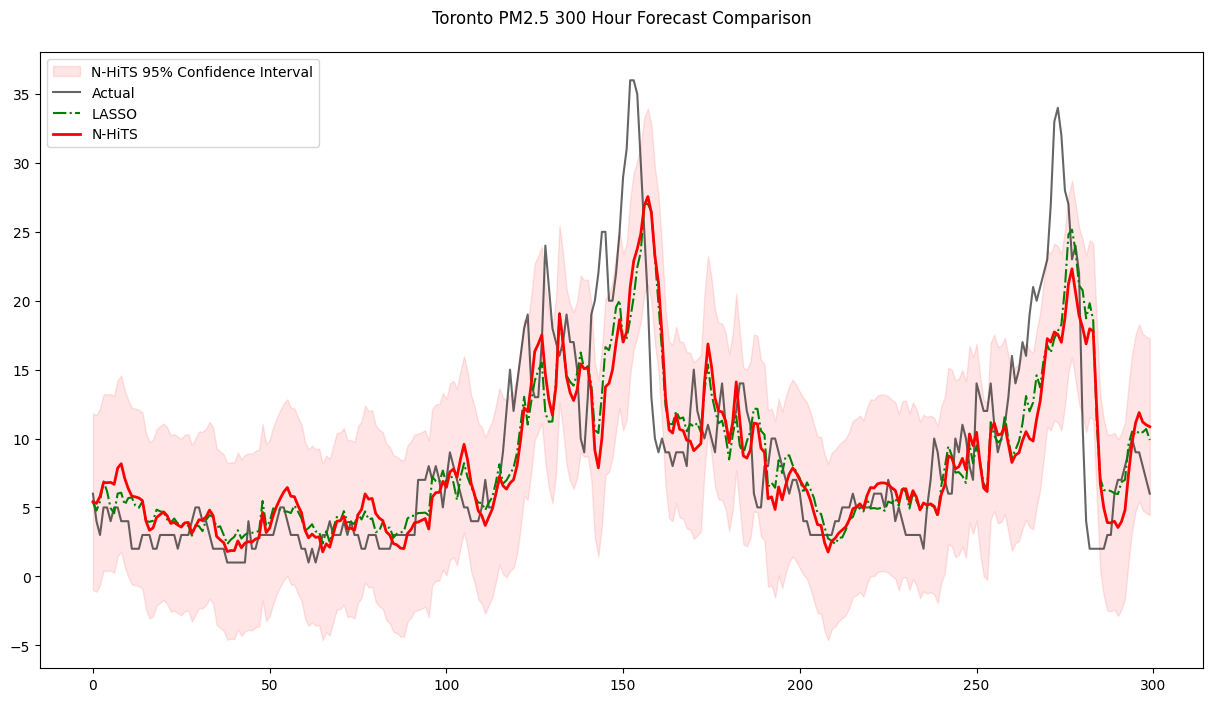

In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# Import our custom classes from the src folder!
from modules.nhits_model import RealNHITS
from modules.dataset import AQDataset

def get_metrics(a, p):
    return np.sqrt(mean_squared_error(a, p)), mean_absolute_error(a, p)

# --- EXECUTION ---
device = torch.device("cpu") 
data_path = "data/data_clean/cleaned_data_toronto_downtown.csv" 
df = pd.read_csv(data_path, low_memory=False)

features = ['PM_ppb', 'Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Stn Press (kPa)', 
            'Dew Point Temp (°C)', 'Precip. Amount (mm)', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

# 1. Scale Data (Fit on 70% Train)
train_size = int(len(df) * 0.7)
scaler = StandardScaler()
scaler.fit(df.iloc[:train_size][features])
scaled_data_array = scaler.transform(df[features])
pm_mean, pm_std = scaler.mean_[0], scaler.scale_[0]

# Set Hyperparameters based on your GPU sweep results
BEST_LOOKBACK = 24
BEST_HIDDEN = 128  # Updated from 512 to match your winning config!
BEST_DROP = 0.1

# 2. Setup DataLoaders
dataset = AQDataset(scaled_data_array, seq_len=BEST_LOOKBACK)
n = len(dataset)
train_idx, val_idx = int(0.7 * n), int(0.85 * n)

val_loader = DataLoader(Subset(dataset, range(train_idx, val_idx)), batch_size=128)
test_loader = DataLoader(Subset(dataset, range(val_idx, n)), batch_size=128)

# 3. Train LASSO Baseline
print("Training LASSO Baseline...")
X_all = np.array([scaled_data_array[i : i + BEST_LOOKBACK].flatten() for i in range(n)])
y_all = np.array([scaled_data_array[i + BEST_LOOKBACK + 3, 0] for i in range(n)])

X_train_lasso, y_train_lasso = X_all[:val_idx], y_all[:val_idx]
X_test_lasso = X_all[val_idx:]

lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=42, max_iter=10000, n_jobs=-1)
lasso.fit(X_train_lasso, y_train_lasso)
lasso_preds = (lasso.predict(X_test_lasso) * pm_std) + pm_mean

# 4. Load & Run N-HiTS Inference
print("Running N-HiTS Inference...")
model = RealNHITS(input_dim=11, seq_len=BEST_LOOKBACK, hidden_dim=BEST_HIDDEN, dropout_rate=BEST_DROP)

# Load the weights pulled from the server
model.load_state_dict(torch.load("model/global_champion_nhits.pt", map_location=device))
model.eval()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

# Calculate validation residuals to get margin of error (95% CI)
val_preds, val_acts = [], []
with torch.no_grad():
    for x, y in val_loader:
        val_preds.append(model(x).numpy().flatten())
        val_acts.append(y.numpy().flatten())

val_residuals = np.concatenate(val_acts) - np.concatenate(val_preds)
margin_of_error = 1.96 * np.std(val_residuals) * pm_std

# Generate final test predictions
test_preds, test_acts = [], []
with torch.no_grad():
    for x, y in test_loader:
        test_preds.append(model(x).numpy().flatten())
        test_acts.append(y.numpy().flatten())
        
unscaled_preds = (np.concatenate(test_preds) * pm_std) + pm_mean
unscaled_actuals = (np.concatenate(test_acts) * pm_std) + pm_mean

# 5. Evaluation Metrics
l_rmse, l_mae = get_metrics(unscaled_actuals, lasso_preds)
n_rmse, n_mae = get_metrics(unscaled_actuals, unscaled_preds)

print(f"\n--- RESULTS (N={len(unscaled_actuals)}) ---")
print(f"LASSO       | RMSE: {l_rmse:.4f} | MAE: {l_mae:.4f}")
print(f"N-HiTS      | RMSE: {n_rmse:.4f} | MAE: {n_mae:.4f}")

# 6. Plotting
PLOT_LEN = 300
plt.figure(figsize=(15, 8))

plt.fill_between(range(PLOT_LEN), 
                 unscaled_preds[:PLOT_LEN] - margin_of_error, 
                 unscaled_preds[:PLOT_LEN] + margin_of_error, 
                 color='red', alpha=0.1, label="N-HiTS 95% Confidence Interval")

plt.plot(unscaled_actuals[:PLOT_LEN], label="Actual", color='black', alpha=0.6)
plt.plot(lasso_preds[:PLOT_LEN], label="LASSO", color='green', linestyle='-.')
plt.plot(unscaled_preds[:PLOT_LEN], label="N-HiTS", color='red', linewidth=2)

plt.title(f"Toronto PM2.5 300 Hour Forecast Comparison\n")
plt.legend()
plt.show()